In [181]:
# Firstly, we import the libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
# Then, we load the dataset

df = pd.read_csv("cars.csv")

In [183]:
# Check how big the dataset is
print("Dataset shape:", df.shape)

# All column names
print("\nColumns:")
print(df.columns.tolist())

# Data types of each column
print("\nData types:")
print(df.dtypes)

# only the first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (653721, 56)

Columns:
['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info']

Data types:
id_x                         object
car_rel_url_x                object
datetime_scrape              object
name                         object
price_x                     float64
currency_x                

In [184]:
# General information
print("\nDataset information:")
df.info()

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Summary statistic
print("\nSummary statistics:")
print(df.describe())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_x                      653721 non-null  object 
 1   car_rel_url_x             653721 non-null  object 
 2   datetime_scrape           653721 non-null  object 
 3   name                      653721 non-null  object 
 4   price_x                   653721 non-null  float64
 5   currency_x                653721 non-null  object 
 6   datetime_product          653721 non-null  object 
 7   city                      653721 non-null  object 
 8   day                       653721 non-null  object 
 9   hour                      653721 non-null  object 
 10  attributes                653721 non-null  object 
 11  production_year           653721 non-null  int64  
 12  engine_displacement_num   653721 non-null  float64
 13  engine_displacement_un

# Checkpoint 1: Train/Test Split Before Preprocessing

Before building the machine learning model, the dataset must be divided into a training set and a testing set. The training set is used to train the model, while the testing set is reserved for evaluating its performance on unseen data.
The train/test split is performed before any preprocessing to prevent data leakage, ensuring that information from the test set is not influence the training process.
In this project, the goal is to predict the selling price of a car. Therefore, **`price_x`** was selected as the target variable because it contains the numerical price of each vehicle, making this a **regression** problem. All remaining columns that describe the characteristics of the vehicle will be used as the input features, while identifier, duplicate, and information-leaking columns will be excluded.
The dataset will be divided into **80% training data** and **20% testing data** using `train_test_split()`.

In [185]:
# Our target variable
target = "price_x"

**Feature Selection Before Train/Test Split**

Before performing the train/test split, I removed features that were clearly unsuitable for machine learning based on their meaning and purpose. These included columns that could cause data leakage (such as duplicate price information), identifiers that only represent individual listings, personal seller information, URLs, timestamps, and features that do not describe the vehicle itself.

I also removed extremely high-cardinality categorical features because they would create a very large number of encoded variables and increase the risk of overfitting.

These feature removal decisions were based on the characteristics of the columns and did not involve learning information from the dataset. The preprocessing steps that require learning from the data, such as missing value imputation, scaling, and encoding, were performed only after the train/test split to prevent data leakage.


### Removing Leakage-Prone and Irrelevant Features

Some columns were excluded from the feature set
For example:
`price_y` was removed because it is another version of the price and would allow the model to indirectly see the answer
ID columns such as `id_x`, `cars_id`, and `car_details_id` were removed because they only identify individual listings and do not describe vehicle characteristics
Columns such as `phone`, `owner_name`, and `shop_name` were removed because they contain personal or seller information rather than useful car features
URL and timestamp columns were removed because they describe the data collection process instead of the vehicle itself
Removing these columns helps the model learn general patterns instead of memorizing the dataset.

In [186]:

# We remove the target and columns. Because, these would cause data leakage
columns_to_drop = [
    "price_x",
    "price_y",
    "id_x",
    "id_y",
    "cars_id",
    "car_details_id_x",
    "car_details_id_y",
    "car_rel_url_x",
    "car_rel_url_y",
    "car_rel_url",
    "img_url",
    "phone",
    "vin",
    "owner_name",
    "shop_name",
    "datetime_scrape",
    "datetime_product",
    "datetime",
    "updated",
    "description"
]

# Next we define the feature matrix and target vector
X = df.drop(columns=columns_to_drop)
y = df[target]

print("Number of features:", X.shape[1])
print("Target variable:", y.name)

Number of features: 36
Target variable: price_x


### Handling High-Cardinality Categorical Features
After checking the categorical variables, I noticed that some features contain thousands of unique values
For example:
`attributes`: 88,024 unique values
`Yürüş` : 29,812 unique values
`Mühərrik` : 7,000 unique values
`name` : 2,435 unique values
These columns create a problem for One-Hot Encoding because every unique value becomes a separate feature
This would result in:
a very large feature matrix,
higher memory usage,
slower training,
and possible overfitting because the model may memorize rare categories.
Therefore, these extremely high-cardinality features were removed to create a more efficient model.

In [187]:
# Remove high-cardinality categorical features
# These columns contain many unique values and would create thousands
# of one-hot encoded features, making the model inefficient and prone to memorization.

high_cardinality_columns = [
    "attributes",
    "Yürüş",
    "Mühərrik",
    "extra_info",
    "name"
]

X = X.drop(columns=high_cardinality_columns)

print("Number of features after removing high-cardinality columns:", X.shape[1])

Number of features after removing high-cardinality columns: 31


### Removing Constant Features
After reducing the feature set, I checked whether any columns contained only a single unique value
A feature with only one value provides no information because it cannot help the model distinguish between different cars
For example: if every row has the same value, the model cannot learn any relationship from this feature
Therefore, constant columns were removed before preprocessing.

In [188]:
# Remove constant columns (columns with only one unique value)
constant_columns = [
    col for col in X.columns 
    if X[col].nunique() == 1
]

X = X.drop(columns=constant_columns)

print("Removed constant columns:", constant_columns)
print("Number of features after cleaning:", X.shape[1])

Removed constant columns: ['engine_displacement_unit', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'Qəzalı']
Number of features after cleaning: 22


### Train/Test Split Before Preprocessing

To avoid data leakage, the dataset is divided into training and testing sets before applying any preprocessing technique that learns information from the data.
Operations such as:
scaling numerical values,
calculating missing value statistics,
encoding categorical variables
must only be learned from the training data.
The test set remains completely unseen until final evaluation.
The dataset is split into:
80% training data ; 20% testing data

In [189]:
# Split the Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [190]:
# Verifying the Split
print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training feature set: (522976, 22)
Testing feature set: (130745, 22)
Training target: (522976,)
Testing target: (130745,)


# Checkpoint 2: Data Preprocessing Pipeline
After splitting the dataset into training and testing sets, the next step is to preprocess the data before training the machine learning models.
During EDA, I observed that the selected dataset contains both **numerical** features (such as `production_year`, `engine_displacement_num`, and `kilometrage_num`) and **categorical** features (such as `Marka`, `Model`, `Ban növü`, `Rəng`, and `Ötürücü`). Since machine learning algorithms cannot work directly with text values, the categorical variables must be converted into a numerical representation.

I also found that several features contain missing values. Instead of removing these observations and reducing the size of the dataset, I decided to handle the missing values during preprocessing so that as much useful information as possible is retained.

Preprocessing decisions:
To prepare the data, I selected the following preprocessing strategy:
Numerical features: Missing values will be replaced using the **median**, as it is less affected by outliers than the mean
Numerical features: The data will then be standardized using **`StandardScaler()`** so that features measured on different scales contribute more consistently during model training.
Categorical features: Missing values will be replaced using the most frequent value
Categorical features: Text values will be converted into numerical features using **`OneHotEncoder()`**

To apply different preprocessing methods to numerical and categorical features simultaneously, I will use a **`ColumnTransformer`**. The preprocessing steps will then be combined into a **`Pipeline`**, ensuring that all transformations are learned only from the training data and automatically applied to the testing data. This prevents data leakage and guarantees that the same preprocessing workflow is used during both training and prediction.

In [191]:
# We import all reuired libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [192]:
# Identify numerical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical columns
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 5
Number of categorical features: 17


### Defining Preprocessing Pipelines

The dataset contains both numerical and categorical features. Different preprocessing steps are required for each feature type.

- Numerical features:
  - Missing values are handled using median imputation.
  - Features are scaled using StandardScaler so that numerical variables have similar ranges.

- Categorical features:
  - Missing values are handled using the most frequent value.
  - Categorical variables are converted into numerical representations using One-Hot Encoding.
  - Unknown categories in the test set are ignored to prevent errors during prediction.

In [193]:
# Create the numerical preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [194]:
# Create categorical preprocessing pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [195]:
# Combine both using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [196]:
# Fit preprocessing steps using only the training data
# and transform the training features
X_train_processed = preprocessor.fit_transform(X_train)


# Apply the already learned preprocessing steps to the test data
# without learning any new information from it
X_test_processed = preprocessor.transform(X_test)

In [197]:
# Check the result
print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (522976, 4342)
Testing data after preprocessing: (130745, 4342)


### Preprocessing Result

After preprocessing:

- Missing numerical values were replaced using the median.
- Numerical features were standardized.
- Missing categorical values were replaced using the most frequent category.
- Categorical variables were transformed using OneHotEncoder.

The training and testing datasets now have the same number of features (4342), which confirms that the same preprocessing rules were applied to both datasets.

Importantly, the preprocessing object was fitted only on the training data. The test data was transformed using the already learned transformations, preventing data leakage.

In [198]:
# Check number of unique values in categorical columns

categorical_unique_counts = X_train[categorical_features].nunique().sort_values(ascending=False)

categorical_unique_counts.head(20)

Model                       2360
hour                        1435
Marka                        205
day                           92
city                          75
Şəhər                         75
Ban növü                      35
Rəng                          18
Hansı bazar üçün yığılıb       9
Yerlərin sayı                  8
Sürətlər qutusu                5
Sahiblər                       5
Vəziyyəti                      4
currency_x                     3
currency_y                     3
Ötürücü                        3
Yeni                           2
dtype: int64

In [199]:
categorical_unique_counts.tail(10)

Rəng                        18
Hansı bazar üçün yığılıb     9
Yerlərin sayı                8
Sürətlər qutusu              5
Sahiblər                     5
Vəziyyəti                    4
currency_x                   3
currency_y                   3
Ötürücü                      3
Yeni                         2
dtype: int64

### Model Selection and Training

To compare different regression approaches, two different models were selected:

1. **Ridge Regression**
   - Ridge Regression is a linear model with L2 regularization.
   - It is suitable for datasets with many encoded features because it reduces the impact of highly correlated features and helps prevent overfitting.

2. **Random Forest Regressor**
   - Random Forest is a tree-based ensemble model capable of learning non-linear relationships between car characteristics and prices.
   - Since the dataset contains more than 500,000 training samples and thousands of encoded features, a smaller Random Forest configuration was selected to balance prediction performance with computational requirements.

In [200]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

In [201]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(
    alpha=10
)

# Train the model
ridge_model.fit(
    X_train_processed,
    y_train
)

print("Ridge Regression training completed.")

Ridge Regression training completed.


In [202]:
from sklearn.ensemble import RandomForestRegressor

# Lightweight Random Forest for large dataset
rf_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


### Note on Model Complexity

Since the dataset contains more than 500,000 training samples and thousands of encoded features, a lightweight Random Forest configuration was selected to reduce computational requirements.

The number of trees was limited to 20 and the maximum depth was set to 10. This allows the model to capture non-linear relationships while keeping training time and memory usage suitable for the available hardware.

In [203]:
# Predictions from both trained models

ridge_predictions = ridge_model.predict(X_test_processed)

rf_predictions = rf_model.predict(X_test_processed)

print("Predictions completed.")

Predictions completed.


### Model Evaluation Results

Both models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), since the target variable (`price_x`) is continuous and this task is a regression problem.

The results show that the Random Forest model achieved better performance than Ridge Regression.

Random Forest obtained an MAE of approximately **4,617 AZN**, meaning that its predictions were, on average, around 4,617 AZN away from the actual vehicle prices. Considering that the average vehicle price in the dataset was approximately **31,631 AZN**, the prediction error represents about **14.6% of the average car price**.

The Random Forest model also achieved a lower RMSE (**8,241 AZN**) compared with Ridge Regression (**13,144 AZN**), indicating that it produced fewer large prediction errors.

Compared with Ridge Regression, Random Forest was better able to capture the complex non-linear relationships between vehicle characteristics, such as engine size, production year, mileage, and vehicle specifications, and their market prices.

Therefore, based on the test-set evaluation, **Random Forest was selected as the final model because it achieved the lowest MAE and RMSE among the tested algorithms.**


In [204]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ridge Regression metrics
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)


# Random Forest metrics
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)


# Display results
results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest"
    ],
    "MAE": [
        ridge_mae,
        rf_mae
    ],
    "RMSE": [
        ridge_rmse,
        rf_rmse
    ]
})

results

,Model,MAE,RMSE
0,Ridge Regression,6365.390166,13143.506556
1,Random Forest,4616.740458,8240.500039


### Model Evaluation Results

Both models were evaluated using MAE and RMSE because this is a regression problem where the target variable (`price_x`) is continuous.

The Random Forest model achieved better performance than Ridge Regression.

Random Forest obtained an MAE of approximately **4,617 AZN**, meaning that its predictions were on average about **4,617 AZN away from the actual car prices**. Considering that the average vehicle price in the dataset was approximately **31,631 AZN**, this error represents around **14.6% of the average car price**, indicating that the model achieved a reasonable level of prediction accuracy.

Compared with Ridge Regression, Random Forest reduced both MAE and RMSE, indicating that it was better at capturing the complex **non-linear relationships** between vehicle characteristics and price.

Therefore, Random Forest was selected as the **best-performing model among the tested algorithms**.


## Checkpoint 5: Cross-validation

Although the model was already evaluated on a separate test set, a single train/test split can sometimes produce results that depend on how the data was divided.

To obtain a more reliable estimate of model performance, cross-validation was performed.

Due to the large dataset size and high number of encoded features, Ridge Regression was selected for 5-fold cross-validation because it is computationally more efficient compared with tree-based models.

The model was evaluated using 5-fold cross-validation with negative mean absolute error as the scoring metric. The negative values were converted into positive MAE values for easier interpretation.

The Ridge Regression model achieved the following cross-validation MAE scores:

* Fold 1: 6,491 AZN
* Fold 2: 6,522 AZN
* Fold 3: 6,484 AZN
* Fold 4: 6,487 AZN
* Fold 5: 6,474 AZN

The average cross-validation MAE was approximately **6,492 AZN**, showing that Ridge Regression produced consistent results across different training and validation splits.

A reduced-complexity Random Forest model was also tested using 3-fold cross-validation to examine its stability. This version used fewer trees and a smaller maximum depth than the final Random Forest model because of computational limitations. It achieved an average cross-validation MAE of approximately **7,619 AZN**.

However, these Random Forest cross-validation results cannot be directly compared with the final Random Forest model because a simpler configuration was used. The final model selection was based on the unseen test-set evaluation, where the original Random Forest model achieved the best performance with the lowest MAE and RMSE.

Therefore, Random Forest remained the selected final model due to its stronger generalization performance on the independent test dataset.


In [205]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    ridge_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Convert negative MAE to positive values
cv_mae_scores = -cv_scores

print("Cross-validation MAE scores:")
print(cv_mae_scores)

print("\nAverage CV MAE:", cv_mae_scores.mean())

Cross-validation MAE scores:
[6491.19893725 6521.56140567 6484.49793803 6486.76627388 6474.03717885]

Average CV MAE: 6491.612346735318


In [206]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Small Random Forest for cross-validation
rf_cv_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# 3-fold cross-validation to reduce computation time
rf_cv_scores = cross_val_score(
    rf_cv_model,
    X_train_processed,
    y_train,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Convert negative MAE to positive values
rf_cv_mae_scores = -rf_cv_scores

print("Random Forest Cross-validation MAE scores:")
print(rf_cv_mae_scores)

print("\nAverage Random Forest CV MAE:", rf_cv_mae_scores.mean())

Random Forest Cross-validation MAE scores:
[7605.63525828 7626.98544437 7625.57691051]

Average Random Forest CV MAE: 7619.39920438916


**Cross-validation evaluation**

Although Random Forest achieved a lower MAE on the single test set, cross-validation was performed to evaluate model stability across different data splits.

Ridge Regression achieved an average cross-validation MAE of approximately 6492 AZN, showing consistent performance across all folds.

For Random Forest, a reduced-complexity version was used during cross-validation because of computational limitations. This configuration used fewer trees and shallower depth compared with the final Random Forest model. Therefore, its cross-validation MAE of approximately 7619 AZN should not be directly compared with the final Random Forest test performance.

Based on the test-set evaluation, the final Random Forest model was selected because it achieved the lowest MAE and RMSE by capturing complex non-linear relationships between vehicle characteristics and prices.


## Checkpoint 6: Feature Importance Analysis

### Why analyze feature importance?

After training the models, it is important to understand which features contribute the most to the predictions. Feature importance analysis helps interpret the model's decision-making process and identify which vehicle characteristics have the strongest influence on the predicted car prices.

For this analysis, the **Random Forest Regression model** was selected because tree-based models provide built-in feature importance scores. These scores represent how much each feature contributes to reducing prediction errors during the decision-making process of the trees.

### Feature importance with encoded features

The dataset contains categorical variables that were transformed using **OneHotEncoder** during preprocessing. As a result, the original categorical features were converted into multiple numerical features. For example, a feature such as vehicle brand was expanded into separate encoded variables for each category.

Therefore, feature importance values were calculated using the transformed feature names generated after preprocessing. The features were then ranked based on their importance scores to identify the vehicle characteristics that had the greatest influence on the Random Forest predictions.


In [207]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

Number of processed features: 4342


In [208]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 most important features

feature_importance.head(20)

,Feature,Importance
1,numerical__engine_displacement_num,0.434098
4,numerical__Buraxılış ili,0.277698
2,numerical__kilometrage_num,0.052650
4265,categorical__Ötürücü_Tam,0.034173
3647,categorical__Model_Range Rover,0.028721
0,numerical__production_year,0.027475
4262,categorical__Yerlərin sayı_7,0.018203
4246,categorical__Sürətlər qutusu_Mexaniki,0.010512
1804,categorical__Marka_Rolls-Royce,0.007511
1610,categorical__currency_y_AZN,0.007330


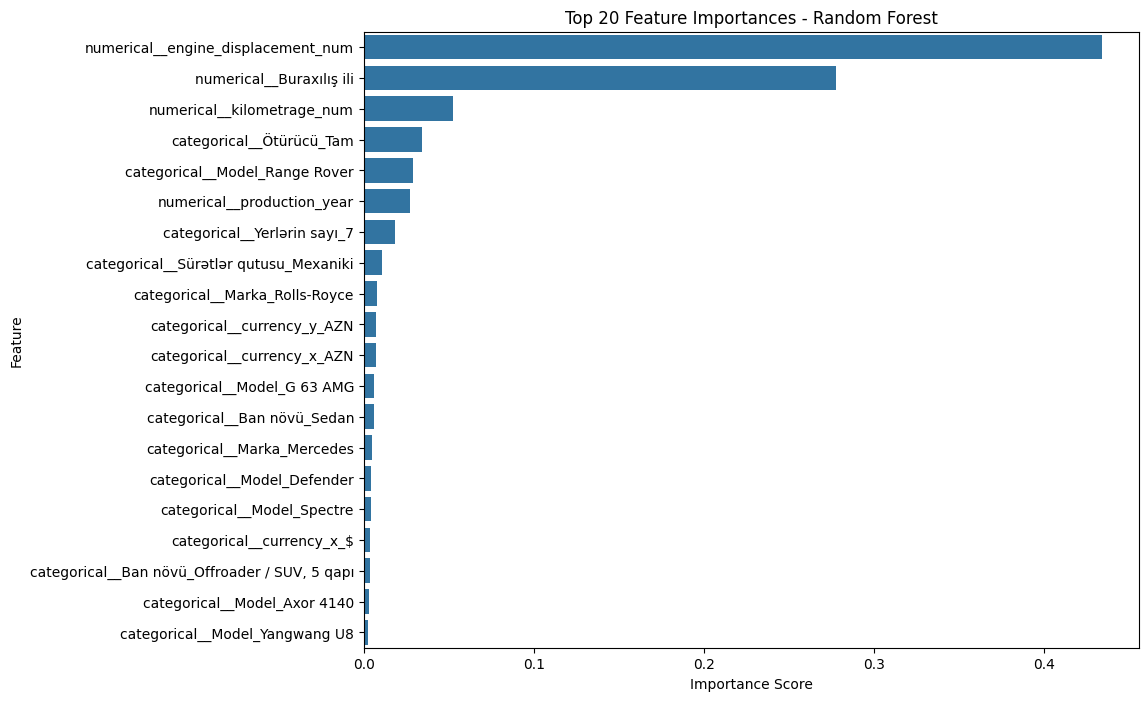

In [209]:
# Plot top 20 important features

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The Random Forest feature importance analysis shows which vehicle characteristics had the strongest influence on the model’s predictions of car prices.

The most important feature was **engine displacement (`engine_displacement_num`)**, which had the highest relative feature importance score of approximately 43%. This means that, among all features provided to the model, engine size was one of the strongest factors used by the Random Forest when predicting vehicle prices.

The second most influential feature was **production year (`Buraxılış ili`)**, with a relative importance score of around 28%. This indicates that the age of a vehicle plays an important role in price prediction, as newer vehicles generally tend to have higher market values.

The vehicle mileage (`kilometrage_num`) was also an important numerical feature. This shows that usage history contributes to price estimation, as vehicles with higher mileage often have lower market values.

Several categorical features also contributed to the model’s predictions, including:

* **Drive type (`Ötürücü_Tam`)**, showing that vehicle specifications such as all-wheel drive can influence predicted prices.
* **Specific vehicle models**, including high-value models such as Range Rover and Mercedes categories, which reflect differences in brand reputation and market demand.
* **Body type and transmission type**, which provide additional information about vehicle characteristics and buyer preferences.

Overall, the feature importance results show that the Random Forest model relied mainly on technical specifications, such as engine size, production year, and mileage, together with vehicle category information when estimating car prices. These results are consistent with common factors that influence real-world vehicle market values.


## Final Conclusion

In this project, a regression workflow was developed to predict car prices using vehicle characteristics.

The dataset was first divided into training and testing sets before applying preprocessing to prevent data leakage. Numerical and categorical features were processed using a ColumnTransformer pipeline, including missing value handling, scaling, and one-hot encoding.

Two regression models were trained and evaluated:
- Ridge Regression as a lightweight linear baseline model.
- Random Forest Regression as a non-linear model capable of capturing complex relationships.

The models were evaluated using MAE and RMSE metrics. Random Forest achieved better performance on the test set, while Ridge Regression showed more stable performance under its cross-validation configuration. However, Random Forest achieved the best test-set performance and was selected as the final model.

Feature importance analysis showed that engine displacement, production year, mileage, and vehicle specifications were among the strongest factors affecting car prices.

Overall, the project demonstrates a complete machine learning workflow including data preparation, model training, evaluation, validation, and interpretation.